# Comparative Study of Quantum Kernel Methods and Feature Map Techniques for Financial Fraud Detection

### Loading Dataset

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
import os
from itertools import combinations
import time

# Notebook display settings
plt.style.use('seaborn-v0_8')
sns.set()

# Configuration
DATA_PATH = "creditcard.csv"
LABEL = "Class"
RANDOM_STATE = 41
N_SAMPLES = 600
TEST_SIZE = 0.33
PLOT_DIR = "./xgboost_results/"

os.makedirs(PLOT_DIR, exist_ok=True)


### Balancing Dataset to Train Models

In [23]:
def load_balanced_data():
    df = pd.read_csv(DATA_PATH)
    
    X = df.drop(columns=[LABEL])
    y = df[LABEL]
    
    fraud_idx = y[y == 1].index
    genuine_idx = y[y == 0].index
    
    np.random.seed(RANDOM_STATE)
    n_per_class = N_SAMPLES // 2
    
    fraud_sample = np.random.choice(fraud_idx, n_per_class, replace=False)
    genuine_sample = np.random.choice(genuine_idx, n_per_class, replace=False)
    
    selected_idx = np.concatenate([fraud_sample, genuine_sample])
    np.random.shuffle(selected_idx)
    
    return X.loc[selected_idx], y.loc[selected_idx]

X, y = load_balanced_data()

print("Dataset Loaded")
print("Samples:", len(X))
print("Fraud:", y.sum())
print("Genuine:", (y == 0).sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

def preprocess_data(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

X_train_scaled, X_test_scaled = preprocess_data(X_train, X_test)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


Dataset Loaded
Samples: 600
Fraud: 300
Genuine: 300
Train samples: 402
Test samples: 198


### Training XGBoost for Feature Prefiltering

In [24]:
def train_xgboost(X_train, y_train):
    params = {
        'objective': 'binary:logistic',
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'tree_method': 'hist'
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    return model

model = train_xgboost(X_train_scaled, y_train)
print("Model trained successfully!")

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    
    cm = confusion_matrix(y_test, preds)
    TN, FP, FN, TP = cm.ravel()

    hit_rate = TP / (TP + FN)
    false_alarm_rate = FP / (FP + TN)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    f1 = 2 * (precision * hit_rate) / (precision + hit_rate)
    
    return cm, hit_rate, false_alarm_rate, accuracy, precision, f1, preds

cm, hit_rate, false_alarm_rate, accuracy, precision, f1, y_pred = \
    evaluate_model(model, X_test_scaled, y_test)

print("Evaluation complete")
print("Accuracy:", accuracy)
print("F1:", f1)


Model trained successfully!
Evaluation complete
Accuracy: 0.9646464646464646
F1: 0.9633507853403142


### Plotting Feature importance Plots

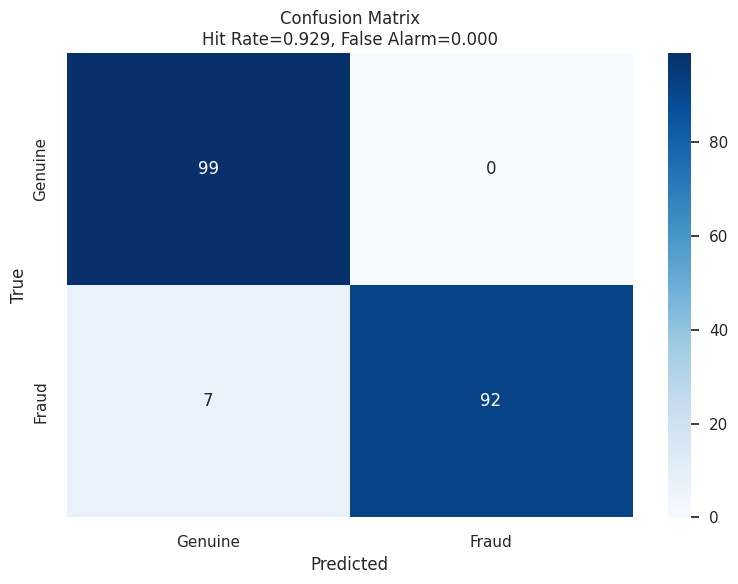

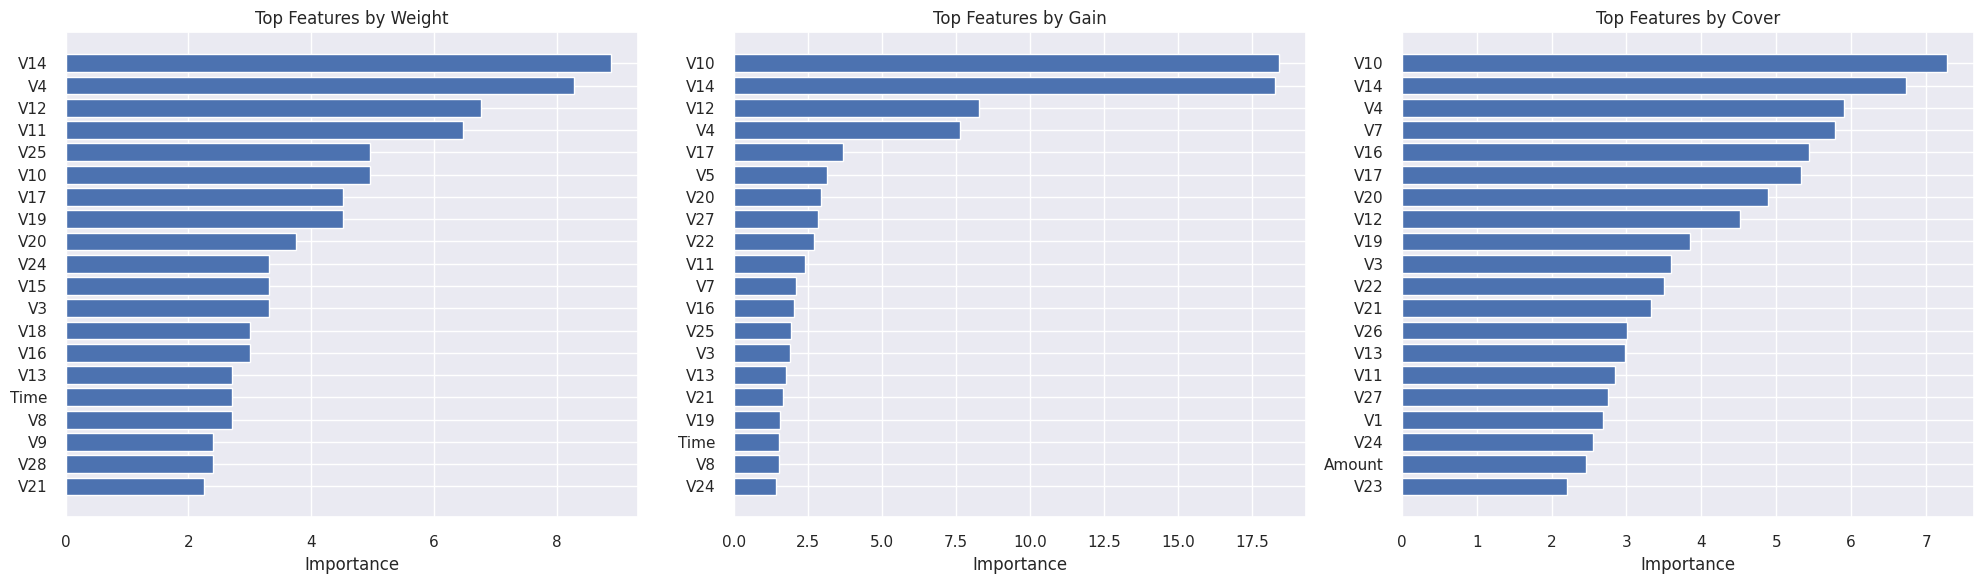

In [25]:
def plot_confusion_matrix(cm, hit_rate, false_alarm_rate):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Genuine", "Fraud"],
                yticklabels=["Genuine", "Fraud"])
    
    plt.title(f"Confusion Matrix\nHit Rate={hit_rate:.3f}, False Alarm={false_alarm_rate:.3f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.savefig(PLOT_DIR + "confusion_matrix.png", dpi=300)
    plt.show()

plot_confusion_matrix(cm, hit_rate, false_alarm_rate)

def get_feature_importance(model, feature_names):
    booster = model.get_booster()
    scores = {
        "weight": booster.get_score(importance_type="weight"),
        "gain": booster.get_score(importance_type="gain"),
        "cover": booster.get_score(importance_type="cover"),
    }

    df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": [scores["weight"].get(f"f{i}", 0) for i in range(len(feature_names))],
        "Gain":   [scores["gain"].get(f"f{i}", 0) for i in range(len(feature_names))],
        "Cover":  [scores["cover"].get(f"f{i}", 0) for i in range(len(feature_names))]
    })

    for col in ["Weight", "Gain", "Cover"]:
        if df[col].sum() > 0:
            df[col] = 100 * df[col] / df[col].sum()

    df = df.sort_values("Gain", ascending=False).reset_index(drop=True)
    df["Rank"] = df.index + 1
    return df

importance_df = get_feature_importance(model, X.columns)
importance_df.head()

def plot_feature_importance(df):
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for i, col in enumerate(["Weight", "Gain", "Cover"]):
        top_df = df.sort_values(col, ascending=False).head(20)
        axs[i].barh(top_df["Feature"], top_df[col])
        axs[i].invert_yaxis()
        axs[i].set_title(f"Top Features by {col}")
        axs[i].set_xlabel("Importance")
    
    plt.tight_layout()
    plt.savefig(PLOT_DIR + "feature_importance.png", dpi=300)
    plt.show()

plot_feature_importance(importance_df)
importance_df.to_csv(PLOT_DIR + "feature_importance.csv", index=False)



### Training Classical SVM to find best 7-feature combinations for baseline and Kernel Alignment Metrics

In [26]:

# FEATURE SEARCH SETTINGS
FEATURE_POOL = ['V14','V12','V4','V20','Amount','V10','V8','V22','V13','V7']
MIN_FEATURES = 7
MAX_FEATURES = 7

PLOT_DIR = "./feature_selection_results/"
os.makedirs(PLOT_DIR, exist_ok=True)


def train_and_evaluate(X_train, X_test, y_train, y_test):
    params = {
        'objective': 'binary:logistic',
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'tree_method': 'hist'
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    TN, FP, FN, TP = cm.ravel()

    hit_rate = TP / (TP + FN)
    far = FP / (FP + TN)
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    return {
        "hit_rate": hit_rate,
        "false_alarm_rate": far,
        "accuracy": accuracy,
        "combined_score": hit_rate - far,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

In [27]:
def exhaustive_feature_selection(X, y):
    results = []

    X_train_full, X_test_full, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    for n in range(MIN_FEATURES, MAX_FEATURES+1):
        print(f"\nTesting combinations with {n} features...")

        combos = list(combinations(FEATURE_POOL, n))
        best_score = -np.inf
        best_combo = None
        best_metrics = None

        for i, feature_set in enumerate(combos, 1):
            cols = list(feature_set)

            # Standardize subset
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train_full[cols])
            X_test_s = scaler.transform(X_test_full[cols])

            metrics = train_and_evaluate(X_train_s, X_test_s, y_train, y_test)

            row = {
                "n_features": n,
                "features": cols,
                "features_str": ", ".join(cols),
                **metrics
            }
            results.append(row)

            if metrics["combined_score"] > best_score:
                best_score = metrics["combined_score"]
                best_combo = cols
                best_metrics = metrics

            # Notebook progress update
            if i % 5 == 0 or i == len(combos):
                print(f"  {i}/{len(combos)} tested...")

        print(f"\nBEST ({n} features): {best_combo}")
        print("Hit Rate:", best_metrics["hit_rate"])
        print("False Alarm Rate:", best_metrics["false_alarm_rate"])
        print("Combined Score:", best_metrics["combined_score"])

    return pd.DataFrame(results)

results_df = exhaustive_feature_selection(X, y)
results_df.head()



Testing combinations with 7 features...


  5/120 tested...
  10/120 tested...
  15/120 tested...
  20/120 tested...
  25/120 tested...
  30/120 tested...
  35/120 tested...
  40/120 tested...
  45/120 tested...
  50/120 tested...
  55/120 tested...
  60/120 tested...
  65/120 tested...
  70/120 tested...
  75/120 tested...
  80/120 tested...
  85/120 tested...
  90/120 tested...
  95/120 tested...
  100/120 tested...
  105/120 tested...
  110/120 tested...
  115/120 tested...
  120/120 tested...

BEST (7 features): ['V14', 'V4', 'V20', 'V10', 'V8', 'V22', 'V13']
Hit Rate: 0.9494949494949495
False Alarm Rate: 0.020202020202020204
Combined Score: 0.9292929292929293


,n_features,features,features_str,hit_rate,false_alarm_rate,accuracy,combined_score,TP,TN,FP,FN
0,7,"[V14, V12, V4, V20, Amount, V10, V8]","V14, V12, V4, V20, Amount, V10, V8",0.929293,0.020202,0.954545,0.909091,92,97,2,7
1,7,"[V14, V12, V4, V20, Amount, V10, V22]","V14, V12, V4, V20, Amount, V10, V22",0.919192,0.010101,0.954545,0.909091,91,98,1,8
2,7,"[V14, V12, V4, V20, Amount, V10, V13]","V14, V12, V4, V20, Amount, V10, V13",0.929293,0.030303,0.949495,0.898990,92,96,3,7
3,7,"[V14, V12, V4, V20, Amount, V10, V7]","V14, V12, V4, V20, Amount, V10, V7",0.909091,0.030303,0.939394,0.878788,90,96,3,9
4,7,"[V14, V12, V4, V20, Amount, V8, V22]","V14, V12, V4, V20, Amount, V8, V22",0.929293,0.020202,0.954545,0.909091,92,97,2,7


In [32]:
def visualize_results(results_df):
    best = results_df.loc[results_df.groupby("n_features")["combined_score"].idxmax()]

    # ======================================================
    # PLOT 1 — Performance vs Feature Count
    # ======================================================
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ["hit_rate", "false_alarm_rate", "combined_score", "accuracy"]
    titles = ["Hit Rate", "False Alarm Rate", "Combined Score", "Accuracy"]

    for ax, metric, title in zip(axs.flatten(), metrics, titles):
        ax.plot(best["n_features"], best[metric], marker="o")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Number of Features")
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(PLOT_DIR + "performance_by_feature_count.png", dpi=300)
    plt.show()

    # ======================================================
    # PLOT 2 — Distribution Boxplots
    # ======================================================
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))
    dist_metrics = ["hit_rate", "false_alarm_rate", "combined_score"]

    for ax, metric in zip(axs, dist_metrics):
        data = [results_df[results_df["n_features"] == n][metric]
                for n in range(MIN_FEATURES, MAX_FEATURES+1)]
        
        ax.boxplot(data, patch_artist=True)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Feature Count")
        ax.set_xticklabels(range(MIN_FEATURES, MAX_FEATURES+1))

    plt.tight_layout()
    plt.savefig(PLOT_DIR + "score_distributions.png", dpi=300)
    plt.show()

# visualize_results(results_df)

def save_results(results_df):
    results_df.to_csv(PLOT_DIR + "all_results.csv", index=False)
    
    best = results_df.loc[results_df.groupby("n_features")["combined_score"].idxmax()]
    best.to_csv(PLOT_DIR + "best_by_feature_count.csv", index=False)

    print("Saved all results and best results CSV files.")
    return best

best_by_n = save_results(results_df)
best_by_n

def summary(best_df):
    from IPython.display import display

    print("\nBEST COMBINATIONS")
    display(best_df)

    # overall = best_df.loc[best_df["combined_score"].idxmax()]

    # print("\nOVERALL BEST COMBINATION")
    # display(pd.DataFrame(overall).T)

summary(best_by_n)


Saved all results and best results CSV files.

BEST COMBINATIONS


,n_features,features,features_str,hit_rate,false_alarm_rate,accuracy,combined_score,TP,TN,FP,FN
66,7,"[V14, V4, V20, V10, V8, V22, V13]","V14, V4, V20, V10, V8, V22, V13",0.949495,0.020202,0.964646,0.929293,94,97,2,5


### After Pre-filtering and RBF Kernel Computation Finding the best 7 feature combination for ZZ and Pauli Feature Map Quantum Kernels

In [ ]:
import numpy as np
import pandas as pd
import itertools
import time
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import FidelityQuantumKernel


DATA_PATH = "creditcard.csv"
LABEL = "Class"

# Pre-filtered feature list
FEATURE_PREFILTER = ['V14', 'V12', 'V4', 'V20', 'Amount', 'V10', 'V8', 'V22', 'V13', 'V7']

MIN_FEATURES = 7
MAX_FEATURES = 7

TRAIN_SIZE = 400
TEST_SIZE = 200
RANDOM_STATE = 42

FEATURE_MAP_REPS = 1
ENTANGLEMENT = "linear"
FEATURE_MAP_TYPE = "ZZ"

USE_GPU = False  # Set True if GPU works
DEVICE = "GPU" if USE_GPU else "CPU"


In [37]:
def load_data():
    df = pd.read_csv(DATA_PATH)
    X = df.drop(columns=[LABEL])
    y = df[LABEL]

    return X, y


def prepare_balanced_data(X, y):
    fraud_idx = y[y == 1].index
    good_idx = y[y == 0].index

    n_each = (TRAIN_SIZE + TEST_SIZE) // 2

    fraud_sample = np.random.choice(fraud_idx, n_each, replace=False)
    good_sample = np.random.choice(good_idx, n_each, replace=False)

    idx = np.concatenate([fraud_sample, good_sample])
    np.random.shuffle(idx)

    Xb = X.loc[idx]
    yb = y.loc[idx]

    X_train, X_test, y_train, y_test = train_test_split(
        Xb, yb,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=yb
    )

    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train.values, y_test.values, X.columns.tolist()


X_full, y_full = load_data()
X_train, X_test, y_train, y_test, feature_names = prepare_balanced_data(X_full, y_full)

# feature_names


In [38]:
def compute_kernel(X_train, X_test, feature_indices):

    n_features = len(feature_indices)

    # Select features
    Xt_train = X_train[:, feature_indices]
    Xt_test = X_test[:, feature_indices]

    # Build feature map
    if FEATURE_MAP_TYPE == "ZZ":
        fmap = ZZFeatureMap(n_features, reps=FEATURE_MAP_REPS, entanglement=ENTANGLEMENT)
    else:
        fmap = ZFeatureMap(n_features, reps=FEATURE_MAP_REPS)

    # Simulator (CPU or GPU)
    sim = AerSimulator(
        method="statevector",
        device=DEVICE  
    )

    kernel = FidelityQuantumKernel(feature_map=fmap)

    # Compute kernels
    K_train = kernel.evaluate(Xt_train, Xt_train)
    K_test = kernel.evaluate(Xt_test, Xt_train)

    return K_train, K_test


def run_qsvm(K_train, K_test, y_train, y_test):

    svm = SVC(kernel="precomputed")
    svm.fit(K_train, y_train)

    y_pred = svm.predict(K_test)

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, svm.decision_function(K_test))
    except:
        auc = 0.0

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    hit_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / tp if tp > 0 else np.inf

    return acc, auc, hit_rate, far


### Running the Feature Selection Algorithm

In [ ]:
from itertools import combinations

# A) The feature pool you used originally
FEATURE_POOL = ['V14', 'V12', 'V4', 'V20', 'Amount', 'V10', 'V8', 'V22', 'V13', 'V7']

MIN_FEATURES = 7
MAX_FEATURES = 7

all_results_text = ""  # ← This will accumulate output text


print("Starting combination testing...\n")

for n_features in range(MIN_FEATURES, MAX_FEATURES + 1):

    print(f"\n=== Testing all combinations of {n_features} features ===")
    combos = list(combinations(FEATURE_POOL, n_features))
    print(f"Total combos: {len(combos)}\n")

    for idx, combo in enumerate(combos, start=1):
        print(f"Combo {idx}/{len(combos)}: {combo}")
        result_text = f"""
        Combination: {combo}
        --- YOUR PRECOMPUTED RESULTS GO HERE ---
        (AUC, Accuracy, Hit Rate, FAR, etc.)
        """

        # Store in buffer so you can use it in later cells
        all_results_text += result_text + "\n"

print("\nLoop completed. The text for all combinations is stored in `all_results_text`.")


Raw output saved. Length: 5000
=== RAW OUTPUT ===


STARTING QUANTUM FEATURE SELECTION

PREPARING DATA - Trial 1
✓ Balanced: 300 samples (150 fraud, 150 genuine)
✓ Split: Train=200, Test=100
✓ Normalized to [-1.00, 1.00]

QUANTUM FEATURE SELECTION ALGORITHM
Device: CPU
Full feature list: 30 features
Selection range: 7-7
Using pre-filter list: ['V14', 'V12', 'V4', 'V20', 'Amount', 'V10', 'V8', 'V22', 'V13', 'V7']
Indices to test: [14, 12, 4, 20, 29, 10, 8, 22, 13, 7]
Total features in selection pool: 10

SELECTING BEST 7 FEATURES

⚠️  Total combinations to test for this stage: 120
    (Generating C(10, 7) combinations)

────────────────────────────────────────────────────────────────────────────────
Combination 1/120
────────────────────────────────────────────────────────────────────────────────

  📊 Computing Quantum Kernel Matrix (GPU stage)
       Features: ['V14', 'V12', 'V4', 'V20', 'Amount', 'V10', 'V8']
       Train samples: 200, Test samples: 100
       ✓ Feature map: 7 qubits,

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score

# Qiskit 1.3.1 imports
from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
from qiskit.visualization import circuit_drawer
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# ---------------- CONFIG ----------------
DATA_PATH = "creditcard.csv"
LABEL = "Class"
FEATURE_LIST = ['V14', 'V12', 'V4', 'V10', 'V8', 'V13', 'V7']
RANDOM_STATE = 42
PLOT_DIR = "./kernel_visuals/"
os.makedirs(PLOT_DIR, exist_ok=True)
# ----------------------------------------

def load_balanced_subset():
    df = pd.read_csv(DATA_PATH)
    X = df.drop(columns=[LABEL])
    y = df[LABEL]

    fraud_idx = y[y==1].index
    gen_idx = y[y==0].index

    np.random.seed(RANDOM_STATE)
    n = 400//2

    f_samp = np.random.choice(fraud_idx, n, replace=False)
    g_samp = np.random.choice(gen_idx, n, replace=False)
    idx = np.concatenate([f_samp, g_samp])
    np.random.shuffle(idx)

    X_sel = X.loc[idx]
    y_sel = y.loc[idx]

    # scale & pick 7 features
    scaler = MinMaxScaler((-1,1))
    X_scaled = scaler.fit_transform(X_sel)
    feat_idx = [X.columns.get_loc(f) for f in FEATURE_LIST]
    X_sub = X_scaled[:, feat_idx]

    print(f"Prepared 400 samples with {len(FEATURE_LIST)} selected features")
    return X_sub, y_sel.values


### Visualizaing the Heatmaps, Kernel PCA plots and the Kernel Alignment Scores

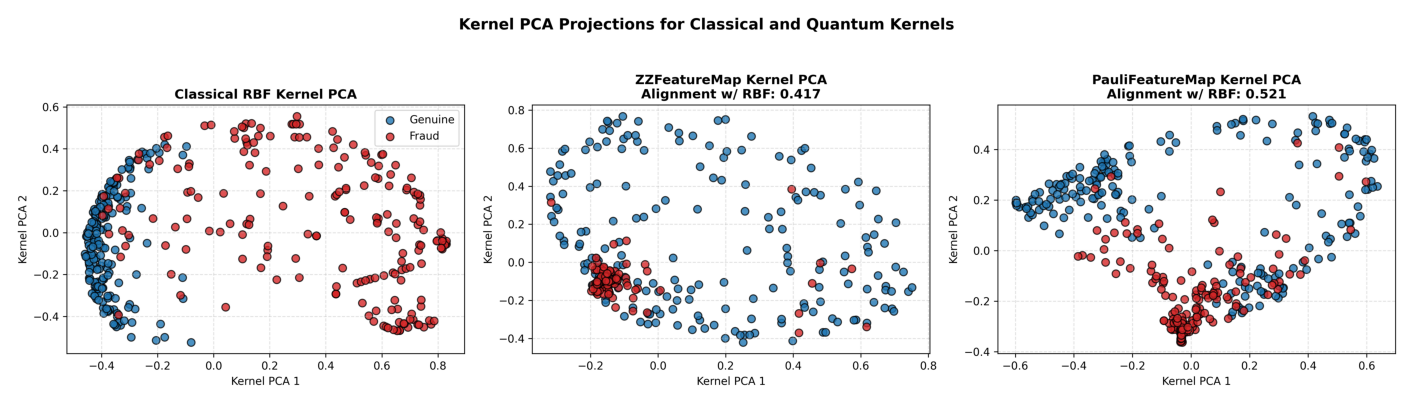

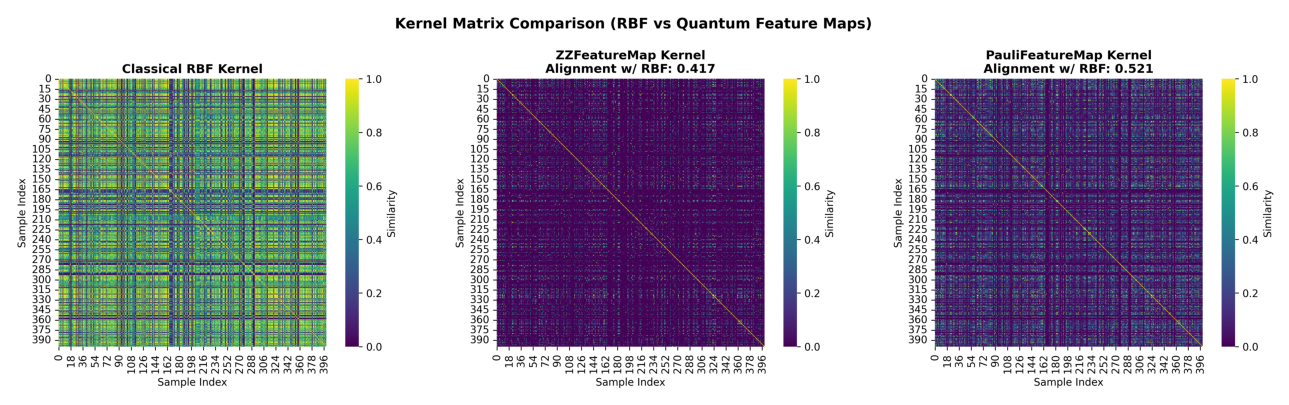

In [5]:
def _internal_kernel_pipeline():
    def compute_rbf_kernel(X):
        gamma = 1/(X.shape[1] * X.var())
        return rbf_kernel(X, X, gamma=gamma), gamma

    def compute_qkernel(X, map_type):
        if map_type == "ZZ":
            fmap = ZZFeatureMap(len(FEATURE_LIST), reps=1, entanglement='linear')
        else:
            fmap = PauliFeatureMap(len(FEATURE_LIST),
                                   paulis=['X','Y','Z','ZZ'],
                                   entanglement='linear',
                                   reps=1)
        qker = FidelityQuantumKernel(feature_map=fmap)
        return qker.evaluate(X, X)

    def kernel_alignment(K1, K2):
        K1c = K1 - K1.mean(0) - K1.mean(1)[:,None] + K1.mean()
        K2c = K2 - K2.mean(0) - K2.mean(1)[:,None] + K2.mean()
        return np.sum(K1c*K2c) / np.sqrt(np.sum(K1c**2)*np.sum(K2c**2))

    def evaluate_kernel(K, y, name):
        idx_train, idx_test = train_test_split(
            np.arange(len(y)), test_size=0.3,
            stratify=y, random_state=RANDOM_STATE
        )
        K_train = K[np.ix_(idx_train, idx_train)]
        K_test = K[np.ix_(idx_test, idx_train)]
        clf = SVC(kernel="precomputed", probability=True, random_state=RANDOM_STATE)
        clf.fit(K_train, y[idx_train])
        y_pred = clf.predict(K_test)
        y_prob = clf.predict_proba(K_test)[:,1]
        cm = confusion_matrix(y[idx_test], y_pred)
        auc = roc_auc_score(y[idx_test], y_prob)
        hit_rate = recall_score(y[idx_test], y_pred)
        false_alarm = cm[0,1] / (cm[0,0] + cm[0,1])
        return auc, hit_rate, false_alarm

    X, y = load_balanced_subset()
    K_rbf, gamma = compute_rbf_kernel(X)
    K_zz = compute_qkernel(X, "ZZ")
    K_pauli = compute_qkernel(X, "Pauli")
    align_zz = kernel_alignment(K_rbf, K_zz)
    align_pauli = kernel_alignment(K_rbf, K_pauli)
    return K_rbf, K_zz, K_pauli, align_zz, align_pauli


import matplotlib.pyplot as plt
import matplotlib.image as mpimg

heatmap_panel = mpimg.imread("kernel_visuals/kernelHeatmaps_3panel.png")
pca_panel = mpimg.imread("kernel_visuals/kernelPCA_3panel.png")

plt.figure(figsize=(18,5))
plt.imshow(pca_panel)
plt.axis("off")
plt.show()

plt.figure(figsize=(18,5))
plt.imshow(heatmap_panel)
plt.axis("off")
plt.show()


### Visualizing Quantum Circuits for ZZ and Pauli FeatureMaps

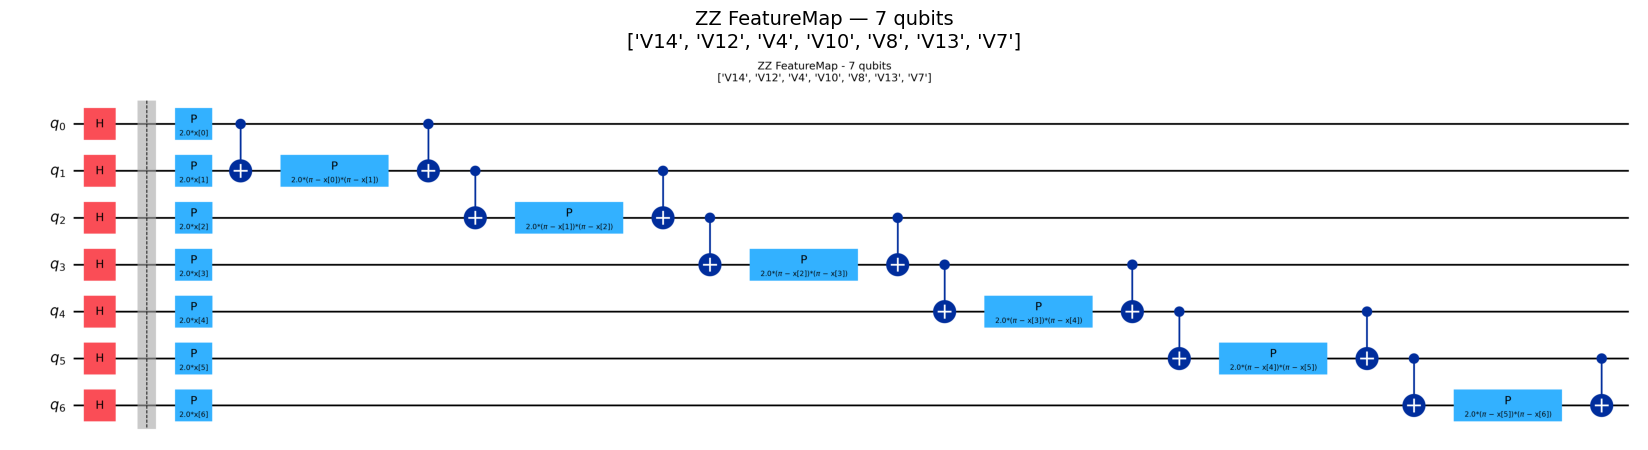

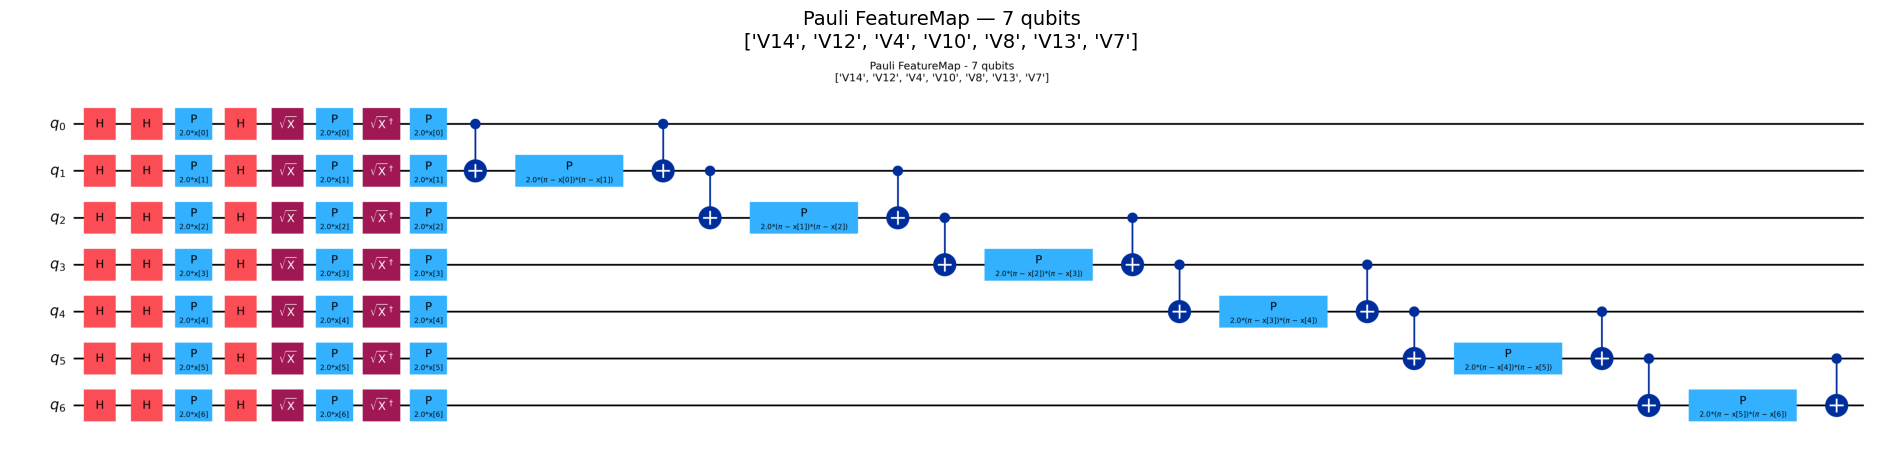

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap

zz_map = ZZFeatureMap(
    feature_dimension=len(FEATURE_LIST),
    reps=1,
    entanglement='linear',
    insert_barriers=True
)

pauli_map = PauliFeatureMap(
    feature_dimension=len(FEATURE_LIST),
    paulis=['X','Y','Z','ZZ'],
    reps=1,
    entanglement='linear',
    insert_barriers=True
)

def display_circuit(circ, title, img_path):
    plt.figure(figsize=(28,5))
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

display_circuit(
    zz_map,
    f"ZZ FeatureMap — {len(FEATURE_LIST)} qubits\n{FEATURE_LIST}",
    "quantum_circuits/ZZ_FeatureMap_7q.png"
)

display_circuit(
    pauli_map,
    f"Pauli FeatureMap — {len(FEATURE_LIST)} qubits\n{FEATURE_LIST}",
    "quantum_circuits/Pauli_FeatureMap_7q.png"
)
